In [1]:
from boundary_extraction import extract_boundary, plot_boundary_stages
from CCH import find_start_point, generate_chain_code, compute_cch, plot_cch_and_image
from scd import (
    smooth_contour, compute_curvature, find_zero_crossings,
    extract_tokens, plot_scd_stages
)

from bas import (
    beam_angle_statistics_full, compress_BAS_with_FD, compress_BAS_by_sampling, plot_BAS_stages
)

from clf import plot_clf, compute_clf

from shock_graph import extract_shock_graph, plot_shock_graph

import numpy as np

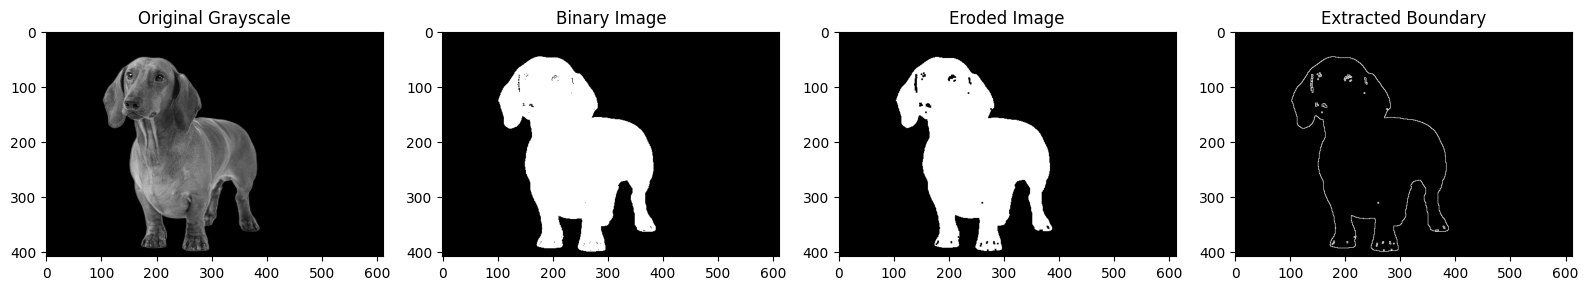

In [2]:
# Đường dẫn ảnh
img_path = '../../animal_datasets_no_bg/gettyimages-108598528-612x612.png'

# 1. Tiền xử lý & trích xuất đường biên
gray, binary, eroded, boundary = extract_boundary(img_path)
plot_boundary_stages(gray, binary, eroded, boundary)


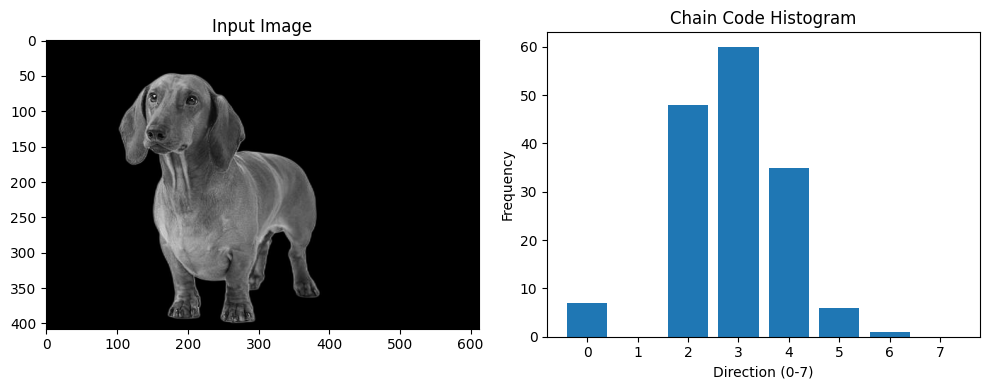

[7, 0, 48, 60, 35, 6, 1, 0]

In [3]:
# 2. Chuỗi mã & CCH
def compute_and_plot_cch(image, boundary):
    start_point = find_start_point(boundary)
    if start_point is None:
        print("No boundary found.")
        return

    chain_code = generate_chain_code(boundary, start_point)
    cch = compute_cch(chain_code)
    plot_cch_and_image(image, cch)
    return cch
compute_and_plot_cch(gray, boundary)

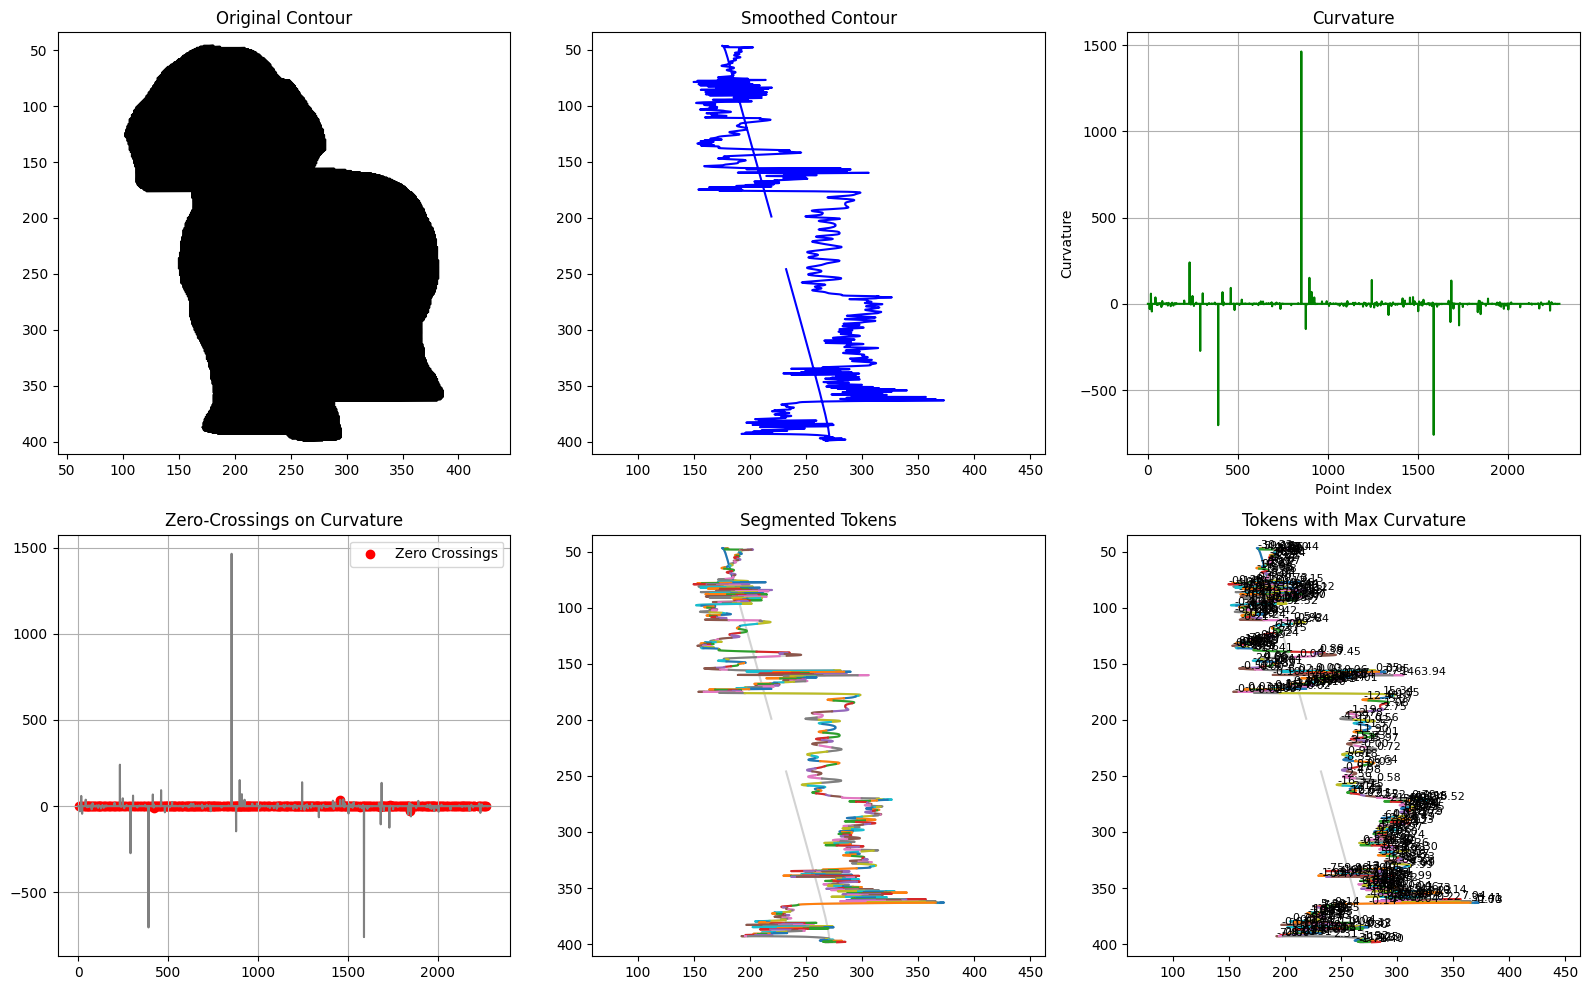

([{'segment': array([[188.30518232,  88.39861988],
          [183.06995124,  69.10497567],
          [179.8485344 ,  57.43739771],
          [177.91460327,  51.1559089 ],
          [176.66170349,  48.17257572],
          [175.7468898 ,  46.95565844],
          [175.09123408,  46.566588  ],
          [174.83675787,  46.69256709],
          [175.01587813,  46.79920609],
          [175.67972398,  46.88146087],
          [176.76613063,  46.9400154 ],
          [178.07408595,  46.98197659]]),
   'max_curvature': np.float64(-30.22364074666239),
   'orientation': np.float64(-1.8129764505998336)},
  {'segment': array([[178.07408595,  46.98197659],
          [179.32512023,  47.01802341],
          [180.25237887,  47.0599846 ],
          [180.62851675,  47.11853913],
          [180.36428761,  47.20079391],
          [179.55708168,  47.30743291]]),
   'max_curvature': np.float64(59.168947874486285),
   'orientation': np.float64(0.21603393940473592)},
  {'segment': array([[179.55708168,  47.307432

In [5]:
# 3. scd
def compute_and_plot_scd(boundary):
    # Chuyển ảnh boundary sang danh sách điểm (x, y)
    coords = np.argwhere(boundary == 1)
    if len(coords) < 5:
        print("Boundary quá ngắn để thực hiện SCD.")
        return
    contour = coords[:, [1, 0]].astype(np.float32)  # (x, y)

    # Thực hiện SCD
    sigma = 3
    contour_smooth = smooth_contour(contour, sigma)
    curvature = compute_curvature(contour_smooth)
    zc = find_zero_crossings(curvature)
    tokens = extract_tokens(contour_smooth, curvature, zc)

    # Hiển thị toàn bộ các bước
    plot_scd_stages(contour, contour_smooth, curvature, zc, tokens)
    return tokens, contour_smooth, curvature, zc
compute_and_plot_scd(boundary)

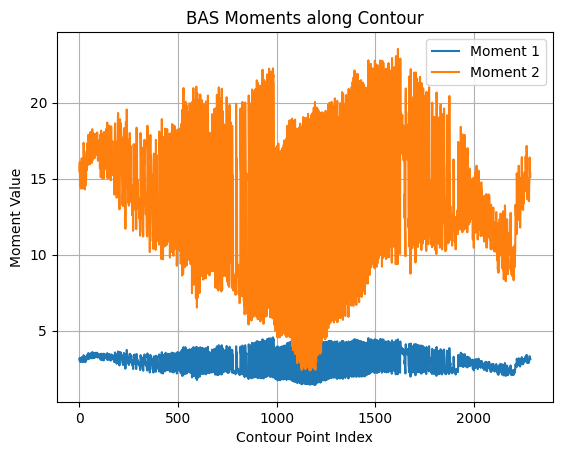

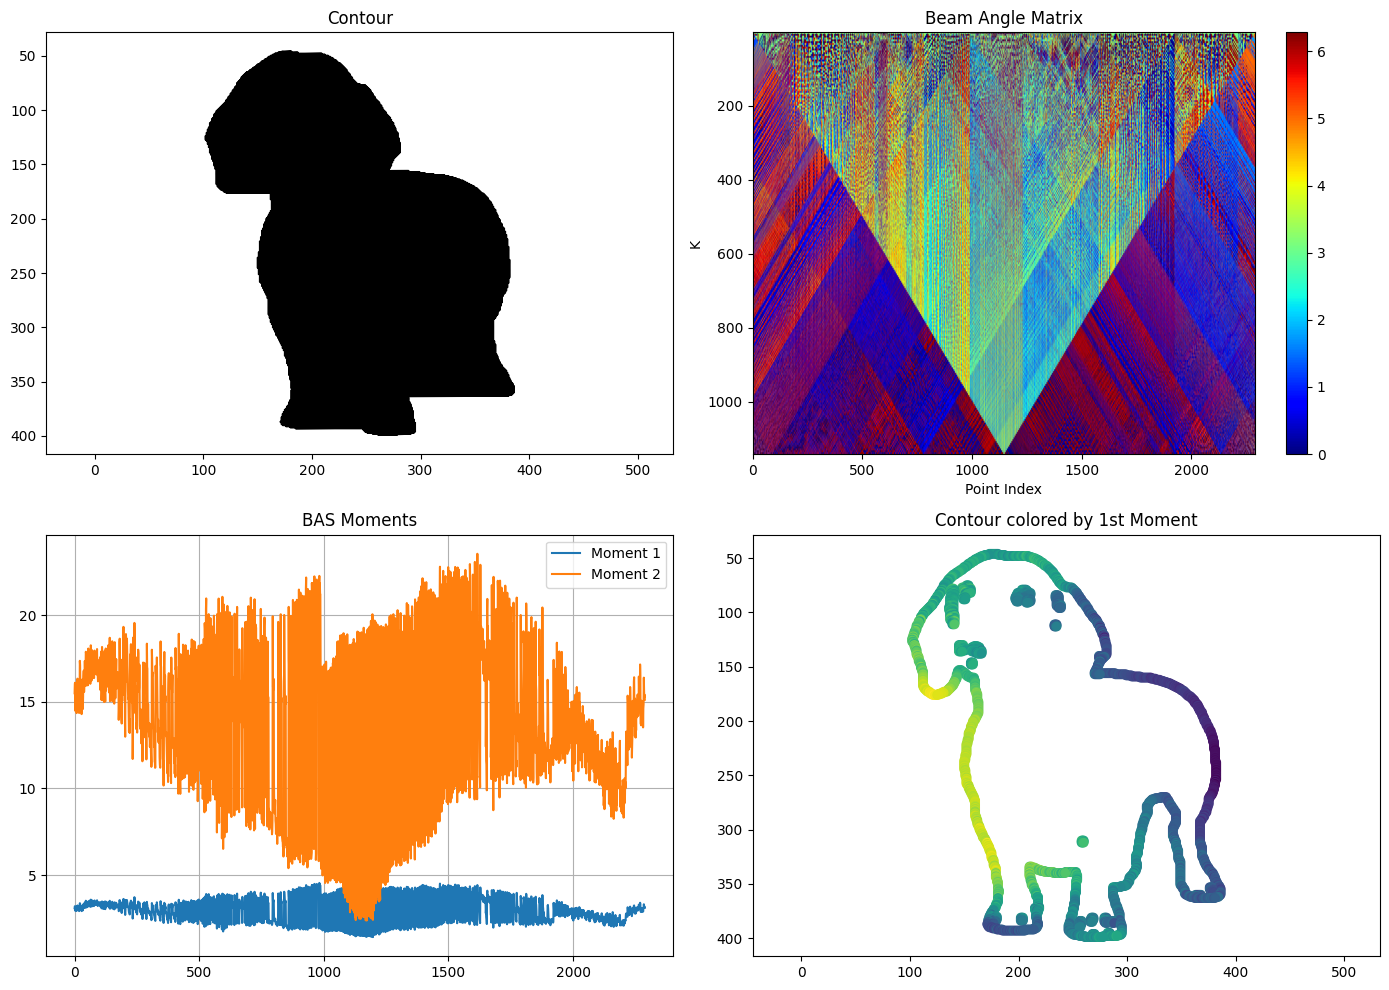

In [12]:
# 4. BAS
def compute_and_plot_bas(contour, m_max=2, K_step=5, bins=30, T_fd=10, sampling_step=5):
    """
    Thực hiện BAS (Beam Angle Statistics) từ contour và hiển thị trực quan các bước.
    Bao gồm:
    - Tính toán CK_matrix (beam angles)
    - Tính moments theo histogram
    - Nén đặc trưng bằng Fourier Descriptor và Sampling
    - Hiển thị trực quan toàn bộ pipeline

    Parameters:
    - contour: ndarray (N x 2), danh sách điểm (x, y)
    """

    moments, CK_matrix, K_list = beam_angle_statistics_full(
        contour, m_max=m_max, K_step=K_step, bins=bins
    )
    feature_fd = compress_BAS_with_FD(moments, T=T_fd)

    feature_sampled = compress_BAS_by_sampling(moments, T=sampling_step)
   
    # 3. Hiển thị trực quan toàn bộ pipeline BAS
    plot_BAS_stages(contour, CK_matrix, moments, K_list)

    return {
        "moments": moments,
        "feature_fd": feature_fd,
        "feature_sampled": feature_sampled
    }

coords = np.argwhere(boundary == 1)
if len(coords) >= 5:
    contour = coords[:, [1, 0]].astype(np.float32)  # (x, y)
    compute_and_plot_bas(contour)
else:
    print("Boundary quá ngắn để thực hiện BAS.")


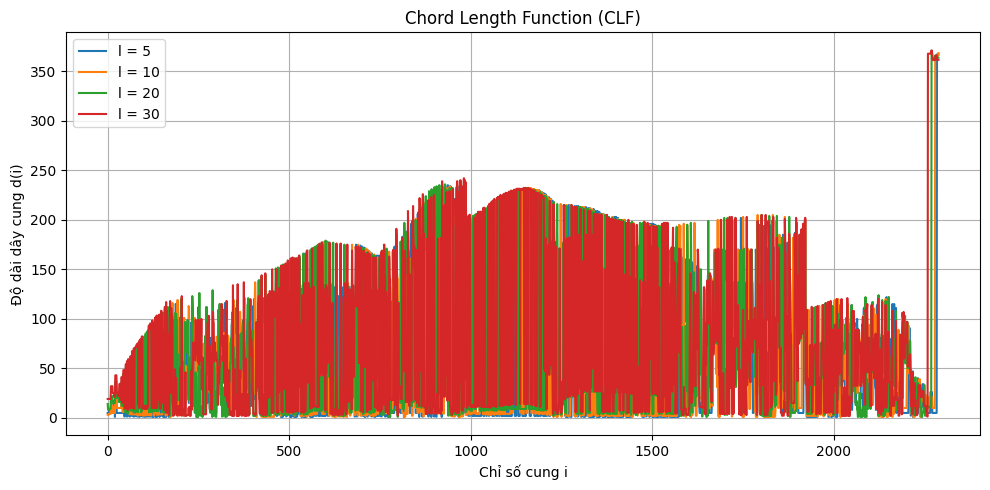

{5: [np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(8.062258),
  np.float32(8.062258),
  np.float32(8.062258),
  np.float32(8.062258),
  np.float32(8.062258),
  np.float32(12.0),
  np.float32(12.0),
  np.float32(12.0),
  np.float32(12.0),
  np.float32(12.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(17.029387),
  np.float32(17.029387),
  np.float32(17.029387),
  np.float32(17.029387),
  np.float32(1.0),
  np.float32(22.0),
  np.float32(22.0),
  np.float32(22.0),
  np.float32(22.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(5.0),
  np.float32(41.01219),
  np.float32(41.01219),
  np.float32(41.01219),
  np.float32(1.4142135),
  np.float32(1.4142135),


In [11]:
# 5. Chord Length Function (CLF)
def compute_and_plot_clf(boundary, arc_length_steps=[5, 10, 20, 30]):
    coords = np.argwhere(boundary == 1)
    if len(coords) < 5:
        print("Boundary quá ngắn để thực hiện CLF.")
        return

    # Chuyển sang (x, y)
    contour = coords[:, [1, 0]].astype(np.float32)
    clf_results = compute_clf(contour, arc_length_steps)
    
    plot_clf(clf_results)
    return clf_results

compute_and_plot_clf(boundary)

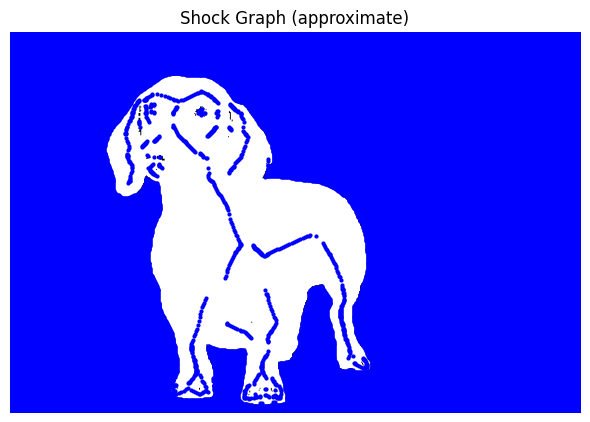

In [14]:
# 6. Shock Graph

boundary_pts, medial_pts = extract_shock_graph(binary, boundary)
plot_shock_graph(binary, boundary_pts, medial_pts)

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
# from main import extract_features_from_image
from shape_feature_extractor import extract_features_from_image
from shape.compute_distance import compute_distance

def numpyify(obj):
    """Chuyển dict chứa list trở lại numpy nếu cần."""
    if isinstance(obj, list):
        return np.array([numpyify(i) for i in obj])
    if isinstance(obj, dict):
        return {k: numpyify(v) for k, v in obj.items()}
    return obj

def load_features(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return [numpyify(d) for d in data]

def find_top_k(query_feat, dataset_feats, k=5):
    distances = []
    for feat in dataset_feats:
        try:
            d = compute_distance(query_feat, feat)
            distances.append((feat['label'], d))
        except Exception as e:
            print(f"Lỗi khi tính khoảng cách với {feat['label']}: {e}")
    distances.sort(key=lambda x: x[1])
    return distances[:k]

def show_binary_images_with_query(query_img_path, top_k_images, title='Top-k Similar Images (with Query)'):
    import cv2
    from boundary_extraction import extract_boundary
    import matplotlib.pyplot as plt
    import os

    total_imgs = 1 + len(top_k_images)  # 1 ảnh gốc + top-K
    fig, axes = plt.subplots(1, total_imgs, figsize=(4 * total_imgs, 4))

    # --- ẢNH GỐC ---
    try:
        _, _, _, query_boundary = extract_boundary(query_img_path)
        axes[0].imshow(query_boundary, cmap='gray')
        axes[0].set_title("Ảnh truy vấn")
        axes[0].axis('off')
    except Exception as e:
        print(f"❌ Không thể đọc ảnh gốc {query_img_path}: {e}")
        axes[0].set_title("Lỗi ảnh gốc")
        axes[0].axis('off')

    # --- Top-K Ảnh ---
    for ax, (img_path, dist) in zip(axes[1:], top_k_images):
        try:
            _, _, _, boundary = extract_boundary(img_path)
            ax.imshow(boundary, cmap='gray')
            ax.set_title(f"{os.path.basename(img_path)}\nDist: {dist:.4f}")
        except Exception as e:
            print(f"❌ Không thể đọc ảnh {img_path}: {e}")
            ax.set_title("Lỗi đọc ảnh")
        ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [13]:
import cv2
import numpy as np
from PIL import Image
image_path = r"C:\Users\VICTUS\Desktop\BTL\Hệ_cơ_sở_dữ_liệu_đa_phương_tiện\animal_datasets_no_bg\gettyimages-218906-612x612.png"
pil_image = Image.open(image_path).convert('L')
image_np = np.array(pil_image)


In [15]:
image_np

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [2]:
query_img = r'C:\Users\VICTUS\Desktop\BTL\Hệ_cơ_sở_dữ_liệu_đa_phương_tiện\animal_datasets_no_bg\gettyimages-218906-612x612.png'
# features_path = 'features.json'

print("📤 Đang trích xuất đặc trưng ảnh truy vấn...")
query_feat = extract_features_from_image(query_img)

# print("📥 Đang tải đặc trưng dataset...")
# dataset_feats = load_features(features_path)

# print("🔍 Đang tìm top-k ảnh gần nhất...")
# top_k = find_top_k(query_feat, dataset_feats, k=5)

# print("\n✅ Top 5 ảnh gần nhất:")
# for label, dist in top_k:
#     print(f"{label} - Distance: {dist:.4f}")

# print("\n🖼️ Hiển thị ảnh nhị phân tương ứng...")
# show_binary_images_with_query(query_img,top_k)


📤 Đang trích xuất đặc trưng ảnh truy vấn...


In [3]:
query_feat['scd_tokens']

[{'segment': array([[200.71300848,  95.14310835],
         [198.84918623,  93.81800687],
         [198.33776178,  93.36554304],
         [198.74802853,  93.31339342]]),
  'max_curvature': 13.881492145209466,
  'orientation': -2.391825228745814},
 {'segment': array([[198.74802853,  93.31339342],
         [200.0959835 ,  93.50131971],
         [202.1685845 ,  93.66198598],
         [205.03730291,  93.79045263],
         [208.54728645,  93.88873488],
         [212.31150605,  93.96531282]]),
  'max_curvature': 0.1863541691112073,
  'orientation': 0.04802736435931164},
 {'segment': array([[212.31150605,  93.96531282],
         [215.73047682,  94.03320773],
         [218.21866446,  94.10598143],
         [219.4051901 ,  94.19551022],
         [219.34298002,  94.30595346],
         [218.47182222,  94.43489145]]),
  'max_curvature': 0.7107436415840414,
  'orientation': 0.0760792610810529},
 {'segment': array([[218.47182222,  94.43489145],
         [217.55384185,  94.57187169],
         [217.22

In [5]:
query_feat['scd_tokens']

[{'segment': array([[200.71300848,  95.14310835],
         [198.84918623,  93.81800687],
         [198.33776178,  93.36554304],
         [198.74802853,  93.31339342]]),
  'max_curvature': 13.881492145209466,
  'orientation': -2.391825228745814},
 {'segment': array([[198.74802853,  93.31339342],
         [200.0959835 ,  93.50131971],
         [202.1685845 ,  93.66198598],
         [205.03730291,  93.79045263],
         [208.54728645,  93.88873488],
         [212.31150605,  93.96531282]]),
  'max_curvature': 0.1863541691112073,
  'orientation': 0.04802736435931164},
 {'segment': array([[212.31150605,  93.96531282],
         [215.73047682,  94.03320773],
         [218.21866446,  94.10598143],
         [219.4051901 ,  94.19551022],
         [219.34298002,  94.30595346],
         [218.47182222,  94.43489145]]),
  'max_curvature': 0.7107436415840414,
  'orientation': 0.0760792610810529},
 {'segment': array([[218.47182222,  94.43489145],
         [217.55384185,  94.57187169],
         [217.22